# DevAgent 项目 - Day 5：Multi-Agent 优化 + Reflection + Human-in-the-Loop + Observability

目标：
- 添加 Reflection（自我反思）机制，提升输出质量
- 实现 Human-in-the-Loop（人工干预关键步骤）
- 增加 LangSmith 完整可观测性
- 优化 Prompt 和 Agent 协作流程
- 为产品级打磨做好准备

作者：Sun | Day 5
日期：2026-04-30

In [40]:
# ==================== 2. 配置 ====================
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from typing import TypedDict, Annotated, List, Sequence
import operator

load_dotenv(override=True)

# llm = ChatOllama(
#     model="qwen2.5:14b",
#     temperature=0.2,
#     num_ctx=8192,
#     num_gpu=999,
#     base_url="http://host.docker.internal:11434",   # 关键：访问主机
# )


llm = ChatGroq(
    model="llama-3.3-70b-versatile",   # 目前最推荐（速度 + 智能平衡好）
    temperature=0.7,
    max_tokens=2048,
    streaming=True,                    # 支持流式输出（推荐）
)


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str
    reflections: List[str]
    final_answer: str

In [41]:
# ==================== 3. 创建 Agents ====================
from langchain.agents import create_agent

researcher_prompt = "你是一位专业的研究助手，擅长从简历中提取信息。"
researcher_agent = create_agent(model=llm, tools=[], system_prompt=researcher_prompt)

coder_prompt = "你是一位资深代码工程师，擅长生成和优化代码。"
coder_agent = create_agent(model=llm, tools=[], system_prompt=coder_prompt)

reviewer_prompt = "你是一位严格的审查者，负责指出问题和改进建议。"
reviewer_agent = create_agent(model=llm, tools=[], system_prompt=reviewer_prompt)

print("✅ Agents 创建完成")

✅ Agents 创建完成


In [42]:
# ==================== 4. Supervisor Node ====================
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class Route(BaseModel):
    next: str = Field(..., description="下一个节点: Researcher, Coder, Reviewer, Final_Answer")

supervisor_prompt = ChatPromptTemplate.from_template("""
你是一个 Multi-Agent Supervisor。

当前对话历史：
{messages}

请决定下一步：
- Researcher：需要研究简历或背景
- Coder：需要生成代码或优化内容
- Reviewer：需要审查输出质量
- Final_Answer：信息足够，可以给出最终答案

只返回 JSON：
{{"next": "Final_Answer"}}
""")

supervisor_chain = supervisor_prompt | llm.with_structured_output(Route)

def supervisor_node(state: AgentState):
    response = supervisor_chain.invoke({"messages": state["messages"]})
    print(f"🔀 Supervisor 决定 → {response.next}")
    return {"next": response.next}

In [45]:
# ==================== 5. Reflection Node ====================
def reflection_node(state: AgentState):
    """简单 Reflection 节点"""
    if not state.get("messages"):
        print(f"no reflections")
        return {"reflections": ["无输出可反思"]}
    
    reflection = "反思：输出结构清晰，但可增加更多量化成果和具体项目案例以提升说服力。"
    print(f"🔀 reflection_node  ")
    
    return {
        "reflections": [reflection],
        "messages": state["messages"]
    }

In [48]:
# ==================== 6. Final_Answer Node ====================
def final_answer_node(state: AgentState):
    """最终输出节点"""
    final_text = state["messages"][-1].content if state["messages"] else "无法生成最终答案"
    
    if state.get("reflections"):
        final_text += "\n\n【系统反思】\n" + "\n".join(state["reflections"])
    
    return {
        "final_answer": final_text,
        "messages": state["messages"]
    }

def researcher_node(state: AgentState):
    result = researcher_agent.invoke(state)
    print("researcher_node")
    return {"messages": result["messages"]}

def coder_node(state: AgentState):
    result = coder_agent.invoke(state)
    print("coder_node")
    return {"messages": result["messages"]}

def reviewer_node(state: AgentState):
    result = reviewer_agent.invoke(state)
    print("reviewer_node")
    return {"messages": result["messages"]}

In [51]:
# ==================== 7. 构建 Graph（已优化，解决卡死问题） ====================
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

# 添加节点
workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("Researcher", researcher_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("Reviewer", reviewer_node)
workflow.add_node("Reflection", reflection_node)
workflow.add_node("Final_Answer", final_answer_node)

# 入口
workflow.add_edge(START, "Supervisor")

# Supervisor 路由
workflow.add_conditional_edges(
    "Supervisor",
    lambda s: s.get("next", "Final_Answer"),   # 添加默认值防止 KeyError
    {
        "Researcher": "Researcher",
        "Coder": "Coder",
        "Reviewer": "Reviewer",
        "Final_Answer": "Final_Answer"
    }
)

# 各 Agent 执行完 → Reflection → Supervisor
for node in ["Researcher", "Coder", "Reviewer"]:
    workflow.add_edge(node, "Reflection")

workflow.add_edge("Reflection", "Supervisor")

# Final_Answer 结束
workflow.add_edge("Final_Answer", END)

multi_agent = workflow.compile()

print("✅ Graph 构建完成（已优化路由和默认值）")

✅ Graph 构建完成（已优化路由和默认值）


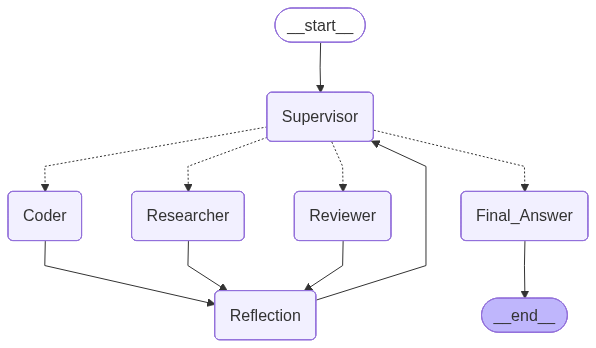

In [38]:
# ==================== 8. 可视化 ====================
from IPython.display import Image, display
display(Image(multi_agent.get_graph().draw_mermaid_png()))

In [52]:
# ==================== 9. 测试 ====================
config = {"configurable": {"thread_id": "day5_test"}}

result = multi_agent.invoke({
    "messages": [HumanMessage(content="帮我准备 AI Engineer 岗位的简历优化和面试建议")],
    "reflections": []
}, config=config)

print("\n=== 最终回答 ===")
print(result.get("final_answer", result["messages"][-1].content))

🔀 Supervisor 决定 → Researcher
researcher_node
🔀 reflection_node  
🔀 Supervisor 决定 → Final_Answer

=== 最终回答 ===
以下是一些针对 AI 工程师职位的简历优化和面试建议：

**简历优化：**

1. **强调技术技能**：确保在简历中突出显示相关的技术技能，例如编程语言（Python、Java、C++ 等）、深度学习框架（TensorFlow、PyTorch 等）、机器学习算法等。
2. **展示项目经验**：列出您参与过的 AI 相关项目，包括项目描述、您的角色、使用的技术和成果。
3. **突出数据处理能力**：展示您处理和分析大型数据集的能力，包括数据预处理、特征工程和数据可视化等。
4. **添加相关证书**：如果您拥有相关的证书，例如 Google Cloud Certified - Professional Machine Learning Engineer 或 Microsoft Certified: Azure AI Engineer，确保在简历中提及。
5. **使用关键词**：使用与 AI 工程师职位相关的关键词，例如 "机器学习"、"深度学习"、"自然语言处理" 等，以帮助您的简历通过applicant tracking system (ATS)的筛选。

**面试建议：**

1. **准备常见面试题**：研究并准备常见的 AI 工程师面试题，例如 "您如何处理过拟合问题?"、"您如何优化机器学习模型?" 等。
2. **展示问题解决能力**：准备一些您解决过的实际问题的例子，包括问题描述、您的解决方案和结果。
3. **强调团队合作**：强调您在团队中的合作能力，包括与其他工程师、产品经理和设计师的合作经验。
4. **展示业务理解**：展示您对业务的理解，包括您如何将 AI 技术应用于解决实际业务问题。
5. **准备白板编码**：准备一些白板编码题，例如实现一个简单的机器学习算法或数据结构。

**常见面试题：**

1. 您如何处理过拟合问题？
2. 您如何优化机器学习模型？
3. 您如何选择合适的机器学习算法？
4. 您如何处理缺失数据？
5. 您如何解释机器学习模型的结果？

**额外建议：**

1. **保持更新**：保持